# Exploratory Data Analysis (EDA) on Retail Sales Data

## Oasis Infobyte Data Analytics Internship

### Objective
To perform Exploratory Data Analysis (EDA) on a retail sales dataset to uncover patterns, customer behavior trends, and actionable business insights.

**Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [29]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Graph style
plt.style.use('ggplot')

# Display all columns
pd.set_option('display.max_columns', None)

In [30]:
# Load Dataset

df = pd.read_csv("Dataset/retail_sales_dataset.csv")

# Display first 5 rows
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Initial Data Inspection

In this section, we examine the dataset's structure, dimensions, data types, and check for missing values.

In [31]:
# Shape of the dataset

print("Shape of Dataset:", df.shape)

# Column names

print("\nColumns:")
print(df.columns)

# Data types

print("\nData Types:")
print(df.dtypes)

# Dataset information

print("\nDataset Information:")
df.info()

Shape of Dataset: (1000, 9)

Columns:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

Data Types:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit   

In [32]:
# Check missing values

df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

### Observation

- The dataset contains **1000 rows** and **9 columns**.
- The dataset includes transaction details, customer demographics, product category, quantity, price, and total amount.
- All columns have appropriate data types.
- No missing values are present in the dataset.
- The dataset is clean and ready for exploratory data analysis.

## Descriptive Statistics

This section provides summary statistics for all numerical columns, including mean, median, mode, and standard deviation.

In [33]:
# Select numerical columns

numerical_columns = df.select_dtypes(include=['int64', 'float64'])

# Mean
print("Mean")
print(numerical_columns.mean())

print("\n" + "="*50)

# Median
print("Median")
print(numerical_columns.median())

print("\n" + "="*50)

# Mode
print("Mode")
print(numerical_columns.mode().iloc[0])

print("\n" + "="*50)

# Standard Deviation
print("Standard Deviation")
print(numerical_columns.std())

Mean
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


### Observation

- The average values provide an overview of customer purchasing behavior.
- Median values help identify the central tendency without the influence of outliers.
- Mode shows the most frequently occurring values.
- Standard deviation indicates the variation in each numerical column.
- The dataset shows variation in customer age, quantity purchased, and total transaction amount.

# Time Series Analysis

In this section, we analyze the monthly and quarterly sales trends to understand how sales change over time.

In [34]:
# Convert Date column into datetime format

df['Date'] = pd.to_datetime(df['Date'])

# Check datatype
df['Date'].dtype

dtype('<M8[us]')

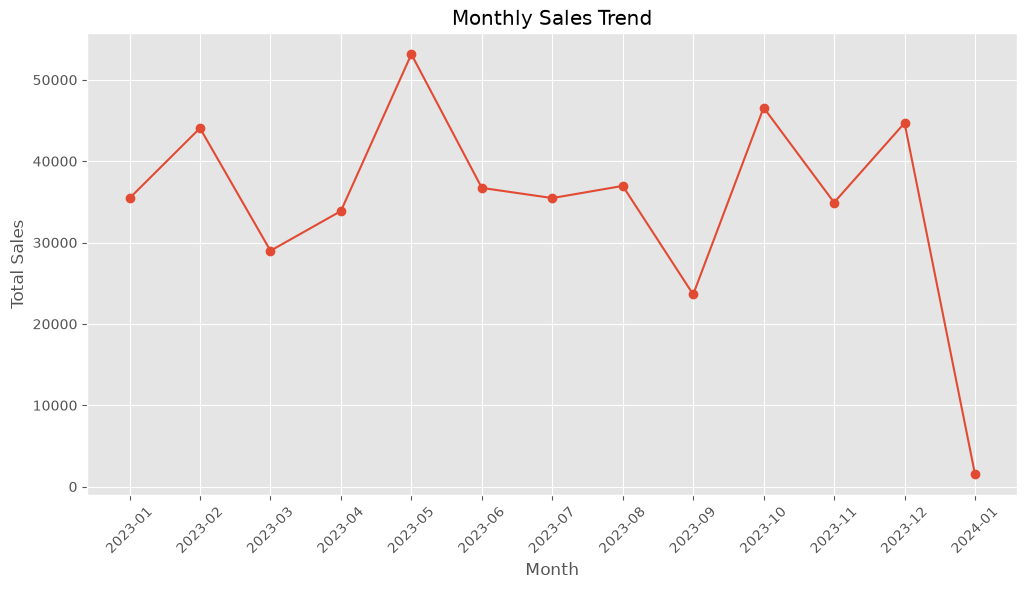

In [35]:
# Create Month-Year column

df['Month'] = df['Date'].dt.to_period('M')

# Monthly Sales

monthly_sales = df.groupby('Month')['Total Amount'].sum()

# Convert index for plotting

monthly_sales.index = monthly_sales.index.astype(str)

# Plot

plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig("Images/monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- The monthly sales trend shows how revenue changes over different months.
- Some months generate higher sales than others.
- Seasonal fluctuations can help businesses plan inventory and marketing campaigns.

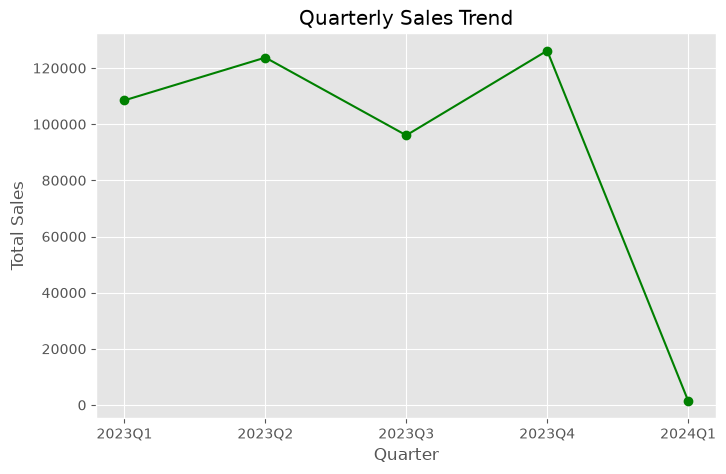

In [36]:
# Create Quarter column

df['Quarter'] = df['Date'].dt.to_period('Q')

# Quarterly Sales

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

quarterly_sales.index = quarterly_sales.index.astype(str)

# Plot

plt.figure(figsize=(8,5))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='o', color='green')
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.savefig("Images/quarterly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- Quarterly sales provide a broader overview of business performance.
- Comparing quarters helps identify long-term growth or decline.
- Businesses can use quarterly trends for strategic planning and forecasting.

# Customer Demographics Analysis

This section analyzes customer demographics, including age distribution and gender distribution.

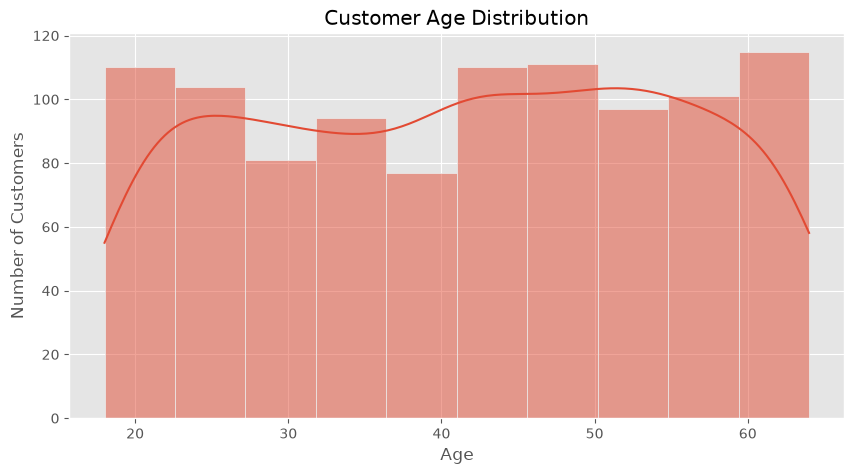

In [37]:
plt.figure(figsize=(10,5))

sns.histplot(df['Age'], bins=10, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.savefig("Images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- The histogram shows the distribution of customer ages.
- Most customers belong to the middle-age group.
- Understanding customer age helps businesses target products to the right audience.

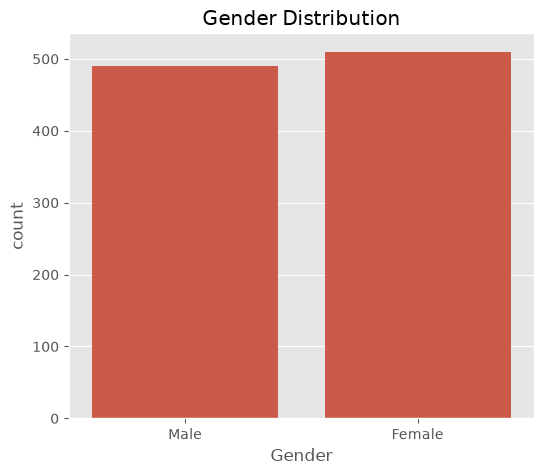

In [38]:
plt.figure(figsize=(6,5))

sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")
plt.savefig("Images/gender_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- The chart shows the number of male and female customers.
- The customer base appears balanced between both genders.
- Businesses can use this information for customer segmentation and marketing strategies.

# Product Analysis

This section analyzes product performance by identifying the top-selling products and revenue generated by each product category.

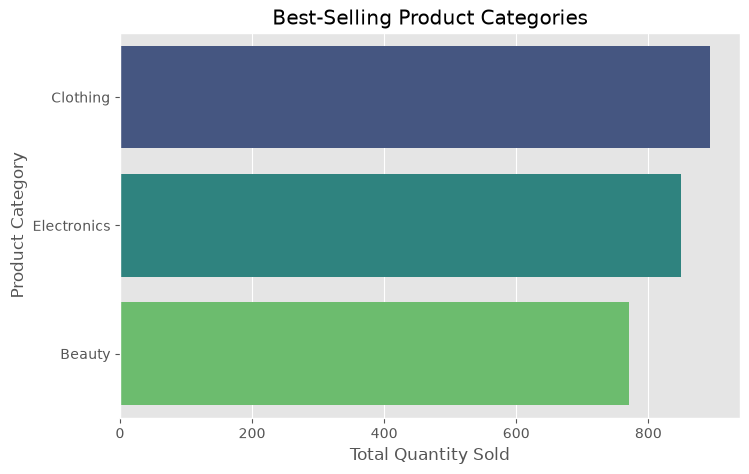

In [39]:
# Top 10 Best-Selling Products

top_products = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette="viridis",
    legend=False
)

plt.title("Best-Selling Product Categories")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Category")
plt.savefig("Images/product_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- Product categories differ in total quantity sold.
- The highest-selling category contributes significantly to total sales.
- Businesses can prioritize inventory based on customer demand.

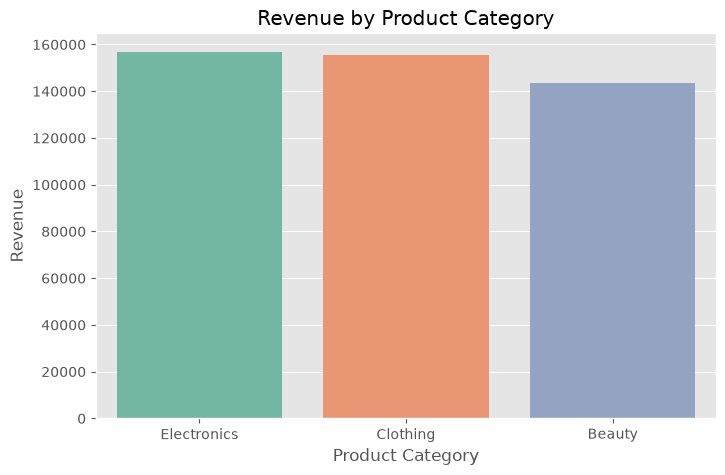

In [40]:
# Revenue by Product Category

category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values,
    hue=category_revenue.index,
    palette="Set2",
    legend=False
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.savefig("Images/revenue_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- Different product categories generate different levels of revenue.
- Some categories earn higher revenue even if their sales quantity is lower.
- Revenue analysis helps businesses identify high-value product categories.

# Correlation Analysis

A correlation heatmap helps identify relationships between numerical variables in the dataset.

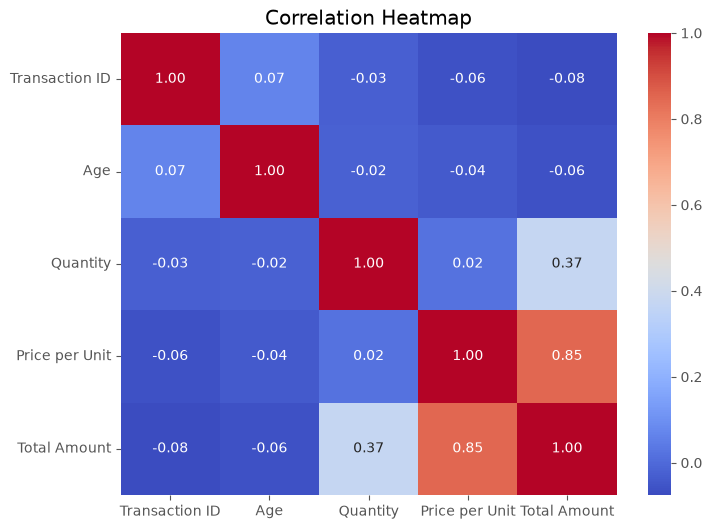

In [41]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("Images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- The heatmap shows the correlation between numerical variables.
- A higher positive correlation indicates that two variables tend to increase together.
- Negative correlation indicates an inverse relationship.
- Understanding these relationships supports better business decision-making.

# Additional Visualization

This visualization shows the average purchase amount across different customer ages to identify spending patterns.

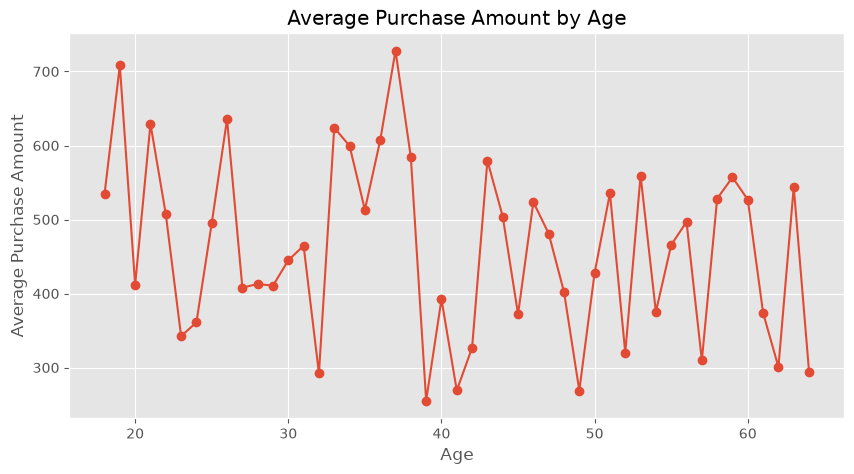

In [42]:
# Average Purchase Amount by Age

age_spending = df.groupby('Age')['Total Amount'].mean()

plt.figure(figsize=(10,5))

plt.plot(age_spending.index, age_spending.values, marker='o')

plt.title("Average Purchase Amount by Age")
plt.xlabel("Age")
plt.ylabel("Average Purchase Amount")

plt.grid(True)
plt.savefig("Images/average_purchase_by_age.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- Customers of different age groups have different spending patterns.
- Some age groups spend more on average than others.
- Businesses can use this information for age-based marketing strategies and personalized offers.

# Conclusion

Based on the analysis, the following business recommendations can be made:

1. Focus marketing campaigns on the highest-performing product categories to maximize revenue.

2. Monitor monthly and quarterly sales trends to improve inventory planning and promotional strategies.

3. Use customer demographic insights, such as age and gender distribution, to design targeted marketing campaigns and improve customer engagement.